# Grounding-Line Synthetic DAS Workflow

This notebook loads the grounding-line SPECFEM2D receiver output, projects it onto a straight fiber direction, and builds a gauge-length DAS strain-rate product that you can use for first-pass reflection analysis.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from io_utils import load_gather
from synthetic import clip_time_window, project_velocity, synthesize_das, fk_filter_velocity_band

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['image.cmap'] = 'Greys'


In [2]:
# Main editable parameters
output_dir = Path('../OUTPUT_FILES')
station_prefix = 'S'   # 'S' is near-surface, 'B' is the shallow buried line
fiber_angle_deg = 0.0 # 0 = horizontal fiber along x
gauge_length_m = 6.28
channel_spacing_m = 6.28
target_phase_velocity_mps = 1900.0  # e.g. ice Vs or Vp
phase_velocity_halfwidth_mps = 300.0
fk_transition_fraction = 0.25
fk_min_frequency_hz = 0.5
plot_tmin = 0.0
plot_tmax = 10.0


In [3]:
gather_x = load_gather(output_dir, component='BXX', station_prefix=station_prefix)
gather_z = load_gather(output_dir, component='BXZ', station_prefix=station_prefix)

print(f'Loaded {gather_x.data.shape[0]} traces with {gather_x.data.shape[1]} samples each')
print(f'x range: {gather_x.x.min():.1f} m to {gather_x.x.max():.1f} m')
print(f't range: {gather_x.time.min():.3f} s to {gather_x.time.max():.3f} s')


Loaded 638 traces with 18000 samples each
x range: -2000.0 m to 2000.0 m
t range: -0.120 s to 10.679 s


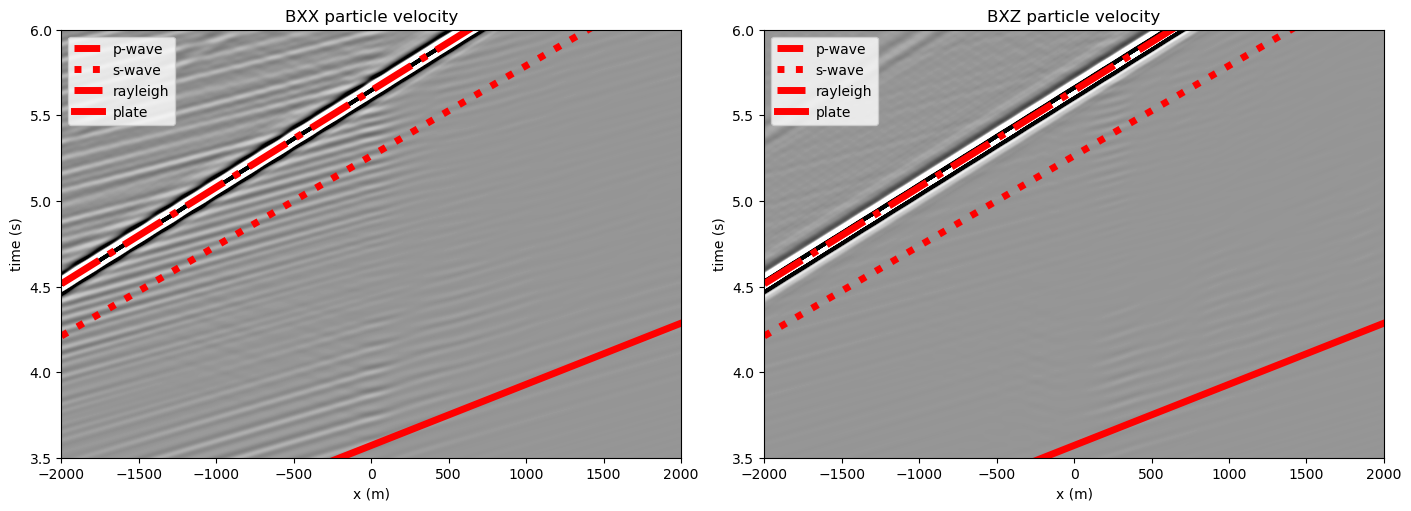

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

clip = np.percentile(np.abs(gather_x.data), 99)
axes[0].imshow(
    gather_x.data.T,
    origin='lower',
    aspect='auto',
    extent=[gather_x.x.min(), gather_x.x.max(), gather_x.time.min(), gather_x.time.max()],
    vmin=-clip,
    vmax=clip,
)
axes[0].set_title('BXX particle velocity')
axes[0].set_xlabel('x (m)')
axes[0].set_ylabel('time (s)')

clip = np.percentile(np.abs(gather_z.data), 99)
axes[1].imshow(
    gather_z.data.T,
    origin='lower',
    aspect='auto',
    extent=[gather_z.x.min(), gather_z.x.max(), gather_z.time.min(), gather_z.time.max()],
    vmin=-clip,
    vmax=clip,
)
axes[1].set_title('BXZ particle velocity')
axes[1].set_xlabel('x (m)')
axes[1].set_ylabel('time (s)')




# Plot p- and s-wave travel time curves
vp = 3800.0
vs = 1900.0
vr = vs* 0.9325
vplate=2800
x = np.linspace(gather_x.x.min(), gather_x.x.max(), 1000)
x0 = -10e3
t_p = np.sqrt((x-x0)**2 + 100.0**2) / vp
t_s = np.sqrt((x-x0)**2 + 100.0**2) / vs
t_r = np.sqrt((x-x0)**2 + 100.0**2) / vr
t_plate=np.sqrt((x-x0)**2 + 100.0**2) / vplate

for ax in axes:
    ax.set_ylim([3.5,6.0])
    ax.plot(x, t_p, 'r--', label='p-wave', linewidth=5)
    ax.plot(x, t_s, 'r:', label='s-wave', linewidth=5)
    ax.plot(x, t_r, 'r-.', label='rayleigh', linewidth=5)
    ax.plot(x, t_plate, 'r-', label='plate', linewidth=5)
    ax.legend()    

plt.show()


In [5]:
fiber_velocity = project_velocity(gather_x, gather_z=gather_z, fiber_angle_deg=fiber_angle_deg)
das = synthesize_das(
    fiber_velocity,
    gauge_length_m=gauge_length_m,
    channel_spacing_m=channel_spacing_m,
)
das_plot = clip_time_window(das, tmin=plot_tmin, tmax=plot_tmax)

print(f'DAS channels: {das.strain_rate.shape[0]}')
print(f'Gauge length: {das.gauge_length_m:.1f} m')
print(f'Channel spacing: {das.channel_spacing_m:.1f} m')


DAS channels: 637
Gauge length: 6.3 m
Channel spacing: 6.3 m


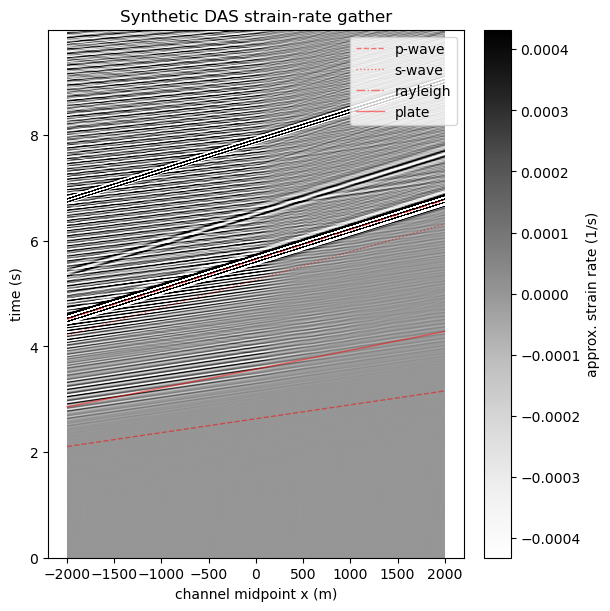

In [6]:
# enable interactive mode so I can zoom in on the plot
# %matplotlib notebook

clip = np.percentile(np.abs(das_plot.strain_rate), 90)

fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
im = ax.imshow(
    das_plot.strain_rate.T,
    origin='lower',
    aspect='auto',
    extent=[das_plot.x.min(), das_plot.x.max(), das_plot.time.min(), das_plot.time.max()],
    vmin=-clip,
    vmax=clip,
)
ax.set_title('Synthetic DAS strain-rate gather')
ax.set_xlabel('channel midpoint x (m)')
ax.set_ylabel('time (s)')
fig.colorbar(im, ax=ax, label='approx. strain rate (1/s)')

# plt.ylim([0,7])
# ax.set_ylim([3.5,6.0])

t0 = 0

# ax.plot(x, t_p, 'w--', label='p-wave', linewidth=5)
# ax.plot(x, t_s, 'w:', label='s-wave', linewidth=5)
# ax.plot(x, t_r, 'w-.', label='rayleigh', linewidth=5)
ax.plot(x, t0+t_p, 'r--', label='p-wave', linewidth=1, alpha=0.5)
ax.plot(x, t0+t_s, 'r:', label='s-wave', linewidth=1, alpha=0.5)
ax.plot(x, t0+t_r, 'r-.', label='rayleigh', linewidth=1, alpha=0.5)
ax.plot(x, t0+t_plate, 'r-', label='plate', linewidth=1, alpha=0.5)
ax.legend()    

# ax.set_ylim([6.75,2.75])
# ax.set_xlim([-1000,-200])

plt.show()


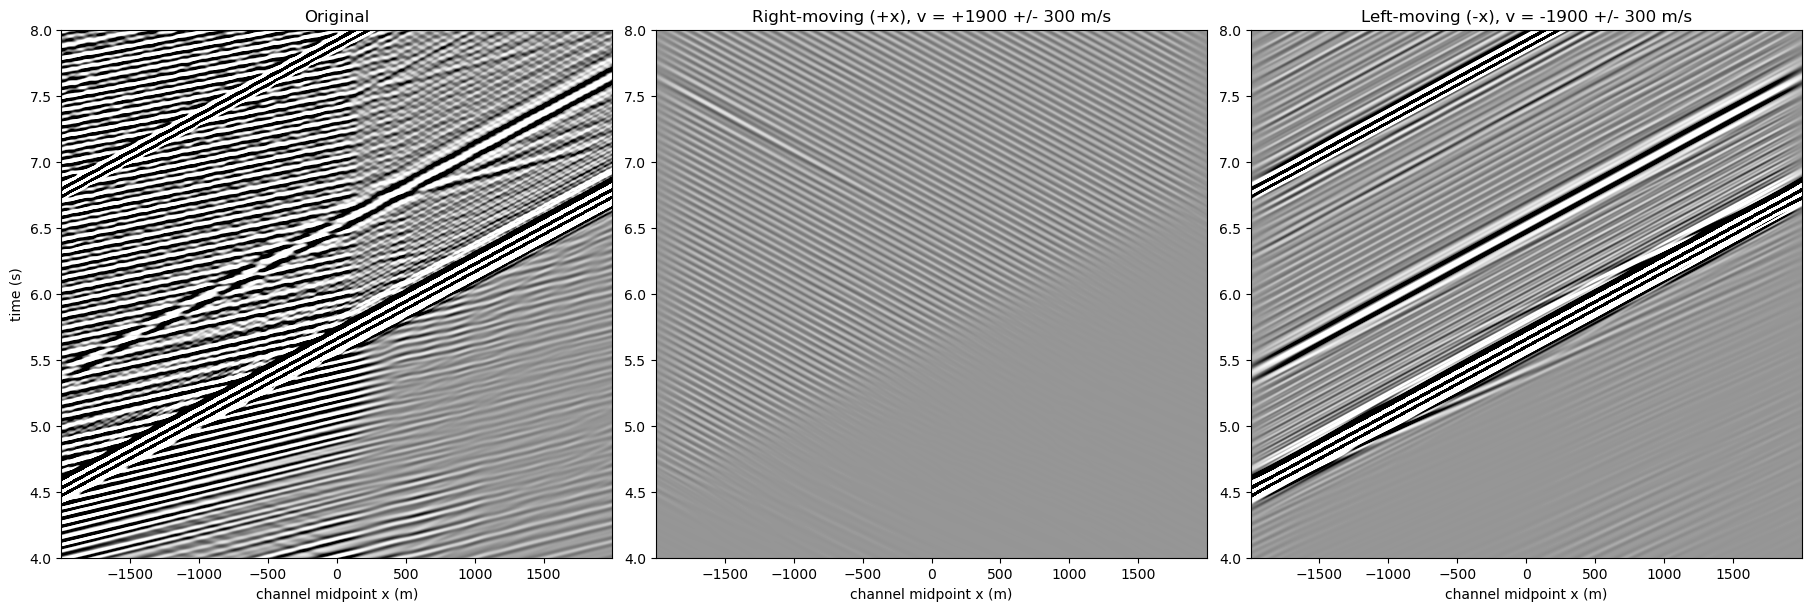

In [7]:
# FK filter: separate left-moving and right-moving waves, but keep only a
# narrow apparent phase-velocity band in each direction. That means the
# right-moving panel corresponds to roughly +v0 and the left-moving panel
# corresponds to roughly -v0.
phase_velocity_min = max(1.0, target_phase_velocity_mps - phase_velocity_halfwidth_mps)
phase_velocity_max = target_phase_velocity_mps + phase_velocity_halfwidth_mps
das_right = fk_filter_velocity_band(
    das,
    phase_velocity_min=phase_velocity_min,
    phase_velocity_max=phase_velocity_max,
    direction='right',
    transition_fraction=fk_transition_fraction,
    min_frequency_hz=fk_min_frequency_hz,
)
das_left = fk_filter_velocity_band(
    das,
    phase_velocity_min=phase_velocity_min,
    phase_velocity_max=phase_velocity_max,
    direction='left',
    transition_fraction=fk_transition_fraction,
    min_frequency_hz=fk_min_frequency_hz,
)
das_right_plot = clip_time_window(das_right, tmin=plot_tmin, tmax=plot_tmax)
das_left_plot = clip_time_window(das_left, tmin=plot_tmin, tmax=plot_tmax)

clip_r = np.percentile(np.abs(das_right_plot.strain_rate), 95)
clip_l = np.percentile(np.abs(das_left_plot.strain_rate), 95)
clip_both = max(clip_r, clip_l)

clip_all = max(clip_r, clip_l)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

# Original
axes[0].imshow(
    das_plot.strain_rate.T, origin='lower', aspect='auto',
    extent=[das_plot.x.min(), das_plot.x.max(), das_plot.time.min(), das_plot.time.max()],
    vmin=-clip_all, vmax=clip_all,
)
axes[0].set_title('Original')
axes[0].set_xlabel('channel midpoint x (m)')
axes[0].set_ylabel('time (s)')

# Right-moving
axes[1].imshow(
    das_right_plot.strain_rate.T, origin='lower', aspect='auto',
    extent=[das_right_plot.x.min(), das_right_plot.x.max(), das_right_plot.time.min(), das_right_plot.time.max()],
    vmin=-clip_all, vmax=clip_all,
)
axes[1].set_title(
    f"Right-moving (+x), v = +{target_phase_velocity_mps:.0f} +/- {phase_velocity_halfwidth_mps:.0f} m/s"
)
axes[1].set_xlabel('channel midpoint x (m)')

# Left-moving
axes[2].imshow(
    das_left_plot.strain_rate.T, origin='lower', aspect='auto',
    extent=[das_left_plot.x.min(), das_left_plot.x.max(), das_left_plot.time.min(), das_left_plot.time.max()],
    vmin=-clip_all, vmax=clip_all,
)
axes[2].set_title(
    f"Left-moving (-x), v = -{target_phase_velocity_mps:.0f} +/- {phase_velocity_halfwidth_mps:.0f} m/s"
)
axes[2].set_xlabel('channel midpoint x (m)')


# for ax in axes:
#     ax.plot(x, t0+t_p, 'r--', label='p-wave', linewidth=2, alpha=0.5)
#     ax.plot(x, t0+t_s, 'r:', label='s-wave', linewidth=2, alpha=0.5)
#     ax.plot(x, t0+t_r, 'r-.', label='rayleigh', linewidth=2, alpha=0.5)
#     ax.plot(x, t0+t_plate, 'r-', label='plate', linewidth=2, alpha=0.5)

for ax in axes:
    ax.set_ylim([4,8])
    # ax.set_xlim([das_plot.x.min(), das_plot.x.max()])

plt.show()


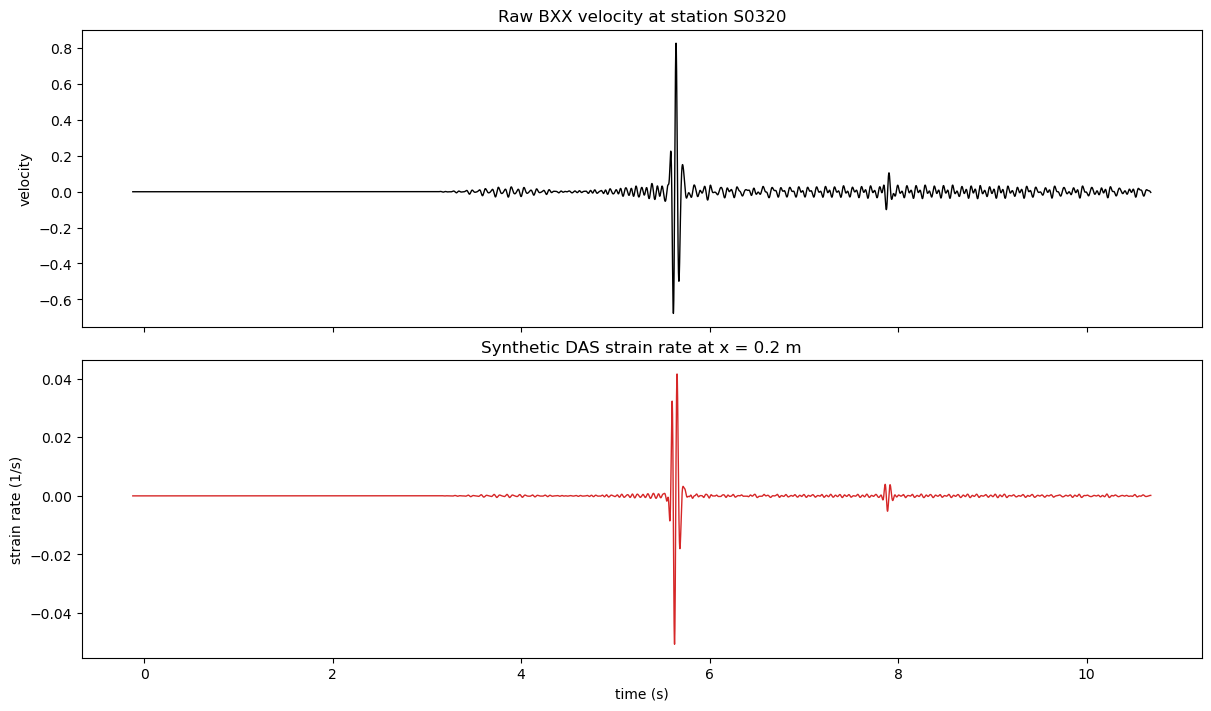

In [8]:
# Compare one raw trace with one DAS channel near the middle of the aperture
mid_trace = gather_x.data.shape[0] // 2
mid_channel = das.strain_rate.shape[0] // 2

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)
axes[0].plot(gather_x.time, gather_x.data[mid_trace], color='black', lw=1.0)
axes[0].set_title(f'Raw BXX velocity at station {gather_x.stations[mid_trace]}')
axes[0].set_ylabel('velocity')

axes[1].plot(das.time, das.strain_rate[mid_channel], color='tab:red', lw=1.0)
axes[1].set_title(f'Synthetic DAS strain rate at x = {das.x[mid_channel]:.1f} m')
axes[1].set_xlabel('time (s)')
axes[1].set_ylabel('strain rate (1/s)')
plt.show()


In [9]:
# Optional: save the DAS product for later use
output_npz = Path('products/surface_das_notebook.npz')
output_npz.parent.mkdir(parents=True, exist_ok=True)
np.savez(
    output_npz,
    time=das.time,
    x=das.x,
    strain_rate=das.strain_rate,
    gauge_length_m=das.gauge_length_m,
    channel_spacing_m=das.channel_spacing_m,
    station_prefix=station_prefix,
)
print(f'Saved {output_npz}')


Saved products/surface_das_notebook.npz


## Notes

- For a horizontal fiber, the main input is `BXX`, because DAS is sensitive to axial deformation along the cable.
- To test a tilted fiber, change `fiber_angle_deg` and rerun the notebook.
- To mimic denser DAS sampling, reduce `channel_spacing_m` as long as your receiver aperture is dense enough to support interpolation.
- To compare buried and surface arrays, switch `station_prefix` between `'S'` and `'B'`.
